<a href="https://colab.research.google.com/github/vuhamodala/Float-Chat-for-Indian-ocean-Data/blob/main/SARIMA_%26_Prophet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

df1 = pd.read_csv("argo_2023.csv")
df2 = pd.read_csv("argo_2024.csv")
df3 = pd.read_csv("argo_2025.csv")

df = pd.concat([df1, df2, df3], ignore_index=True)

print("Total rows:", len(df))

Total rows: 495994


Final time series length: 1096
TIME
2023-01-01    23.974967
2023-01-02    23.549729
2023-01-03    25.901437
2023-01-04    26.177889
2023-01-05    25.827000
Freq: D, Name: TEMP, dtype: float64


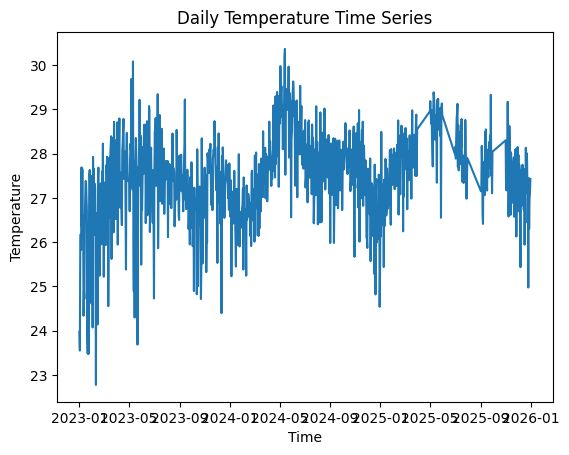

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

df_clean = df.copy()

df_clean = df_clean[['TIME', 'LATITUDE', 'LONGITUDE', 'PRES', 'TEMP']]

df_clean['TIME'] = pd.to_datetime(df_clean['TIME'], errors='coerce')

df_clean = df_clean.dropna(subset=['TIME'])

df_clean = df_clean.dropna(subset=['TEMP'])


df_clean = df_clean.sort_values(by='TIME')

df_clean = df_clean[df_clean['PRES'] <= 100]

ts = df_clean.set_index('TIME')['TEMP']

ts_daily = ts.resample('D').mean()
ts_daily = ts_daily.interpolate()

print("Final time series length:", len(ts_daily))
print(ts_daily.head())

plt.figure()
plt.plot(ts_daily)
plt.title("Daily Temperature Time Series")
plt.xlabel("Time")
plt.ylabel("Temperature")
plt.show()

ts_daily.to_csv("final_timeseries.csv")

from google.colab import files
files.download("final_timeseries.csv")

In [4]:
print(ts_daily.isnull().sum())

0


In [5]:
!pip install statsmodels

In [6]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(ts_daily)

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -2.6804291330056786
p-value: 0.0774865417237633


In [9]:
ts_diff = ts_daily.diff().dropna()

In [10]:
result = adfuller(ts_diff)

print("New p-value:", result[1])

New p-value: 0.0


In [11]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(
    ts_daily,
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

model_fit = model.fit()

print(model_fit.summary())

                                     SARIMAX Results                                      
Dep. Variable:                               TEMP   No. Observations:                 1096
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood               -1285.632
Date:                            Thu, 23 Apr 2026   AIC                           2581.264
Time:                                    22:13:13   BIC                           2606.201
Sample:                                01-01-2023   HQIC                          2590.705
                                     - 12-31-2025                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0712      0.030      2.362      0.018       0.012       0.130
ma.L1         -0.8924      0.017   

In [12]:
model = SARIMAX(
    ts_daily,
    order=(2,1,2),
    seasonal_order=(1,1,1,30)
)

model_fit = model.fit()

print(model_fit.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


                                      SARIMAX Results                                       
Dep. Variable:                                 TEMP   No. Observations:                 1096
Model:             SARIMAX(2, 1, 2)x(1, 1, [1], 30)   Log Likelihood               -1265.349
Date:                              Thu, 23 Apr 2026   AIC                           2544.698
Time:                                      22:16:23   BIC                           2579.494
Sample:                                  01-01-2023   HQIC                          2557.883
                                       - 12-31-2025                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.6854      0.320     -2.143      0.032      -1.312      -0.059
ar.L2         -0.00

In [13]:
model = SARIMAX(
    ts_daily,
    order=(1,1,1),
    seasonal_order=(1,1,1,30)
)

model_fit = model.fit()

print(model_fit.summary())

                                     SARIMAX Results                                      
Dep. Variable:                               TEMP   No. Observations:                 1096
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 30)   Log Likelihood               -1266.165
Date:                            Thu, 23 Apr 2026   AIC                           2542.331
Time:                                    22:18:57   BIC                           2567.184
Sample:                                01-01-2023   HQIC                          2551.748
                                     - 12-31-2025                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0301      0.032      0.926      0.355      -0.034       0.094
ma.L1         -0.8853      0.016   

In [14]:
model = SARIMAX(
    ts_daily,
    order=(0,1,1),
    seasonal_order=(1,1,1,30)
)

model_fit = model.fit()

print(model_fit.summary())

                                     SARIMAX Results                                      
Dep. Variable:                               TEMP   No. Observations:                 1096
Model:             SARIMAX(0, 1, 1)x(1, 1, 1, 30)   Log Likelihood               -1266.545
Date:                            Thu, 23 Apr 2026   AIC                           2541.089
Time:                                    22:21:27   BIC                           2560.972
Sample:                                01-01-2023   HQIC                          2548.623
                                     - 12-31-2025                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.8800      0.014    -63.414      0.000      -0.907      -0.853
ar.S.L30       0.1589      0.030   

In [15]:
forecast = model_fit.forecast(steps=30)

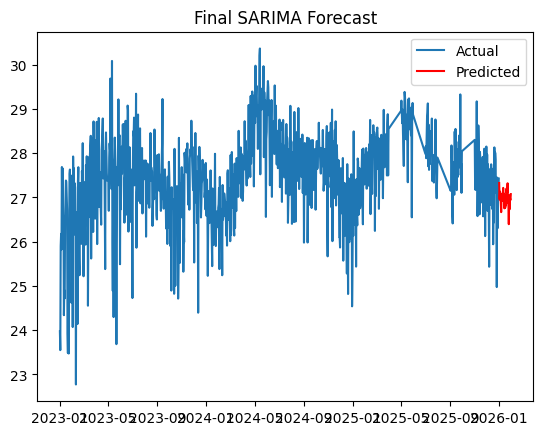

In [16]:
import matplotlib.pyplot as plt
plt.figure()
plt.plot(ts_daily, label="Actual")
plt.plot(forecast, label="Predicted", color="red")
plt.legend()
plt.title("Final SARIMA Forecast")
plt.show()

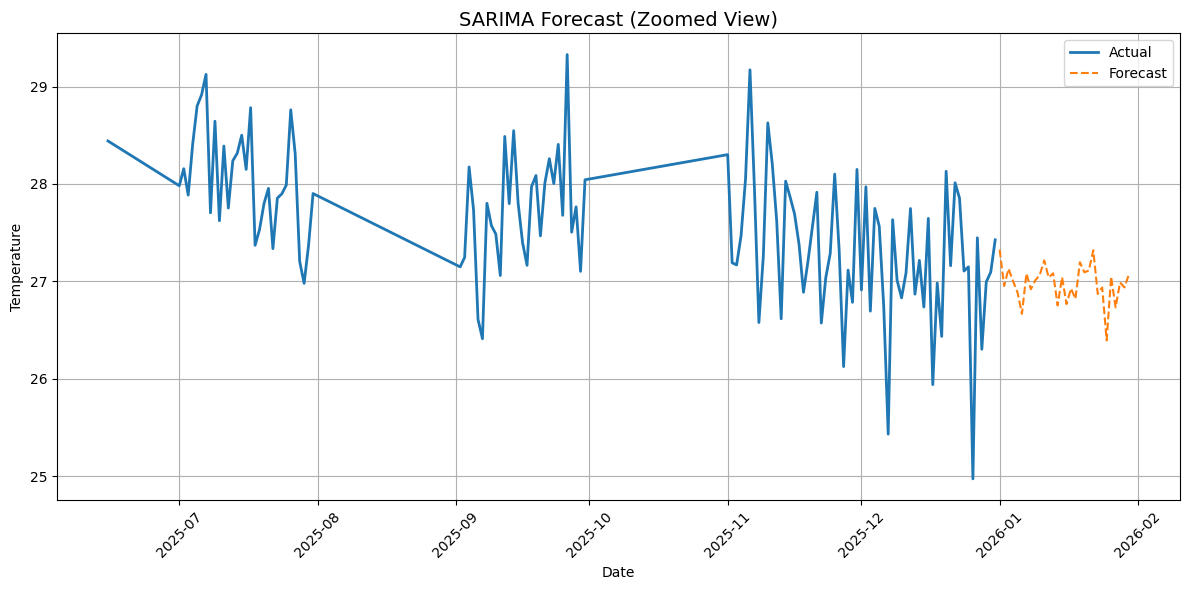

In [17]:
import matplotlib.pyplot as plt
forecast_steps = 30
forecast = model_fit.forecast(steps=forecast_steps)

forecast_index = pd.date_range(
    start=ts_daily.index[-1],
    periods=forecast_steps + 1,
    freq='D'
)[1:]

forecast.index = forecast_index

plt.figure(figsize=(12,6))
plt.plot(ts_daily[-200:], label="Actual", linewidth=2)
plt.plot(forecast, label="Forecast", linestyle='--')
plt.title("SARIMA Forecast (Zoomed View)", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Temperature")
plt.legend()
plt.xticks(rotation=45)

plt.grid(True)
plt.tight_layout()
plt.show()

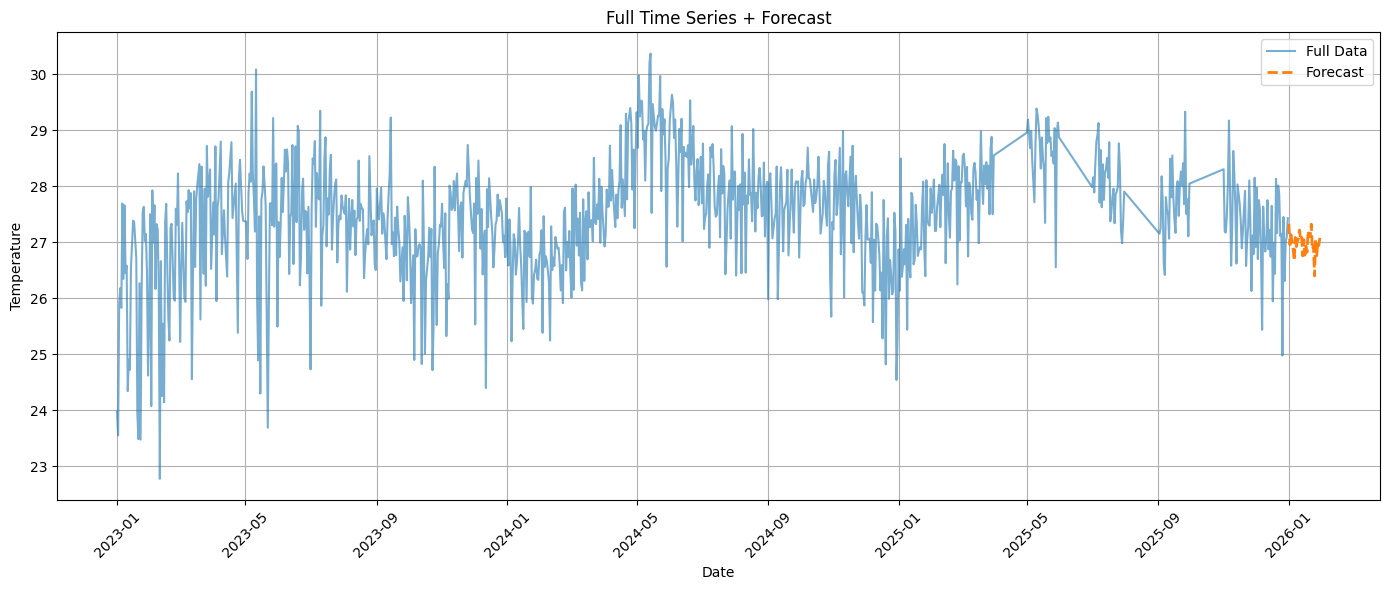

In [18]:
plt.figure(figsize=(14,6))
plt.plot(ts_daily, label="Full Data", alpha=0.6)
plt.plot(forecast, label="Forecast", linestyle='--', linewidth=2)
plt.title("Full Time Series + Forecast")
plt.xlabel("Date")
plt.ylabel("Temperature")
plt.legend()
plt.xticks(rotation=45)

plt.grid(True)
plt.tight_layout()
plt.show()

1 month

In [20]:
train = ts_daily[:-30]
test = ts_daily[-30:]
model = SARIMAX(train, order=(0,1,1), seasonal_order=(1,1,1,30))
model_fit = model.fit()

In [21]:
pred = model_fit.forecast(steps=30)

In [22]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(test, pred)
rmse = np.sqrt(mean_squared_error(test, pred))
mape = np.mean(np.abs((test - pred) / test)) * 100
print("MAPE:", mape)
print("MAE:", mae)
print("RMSE:", rmse)


MAPE: 2.1231209355974454
MAE: 0.567360290989233
RMSE: 0.7472000365583821


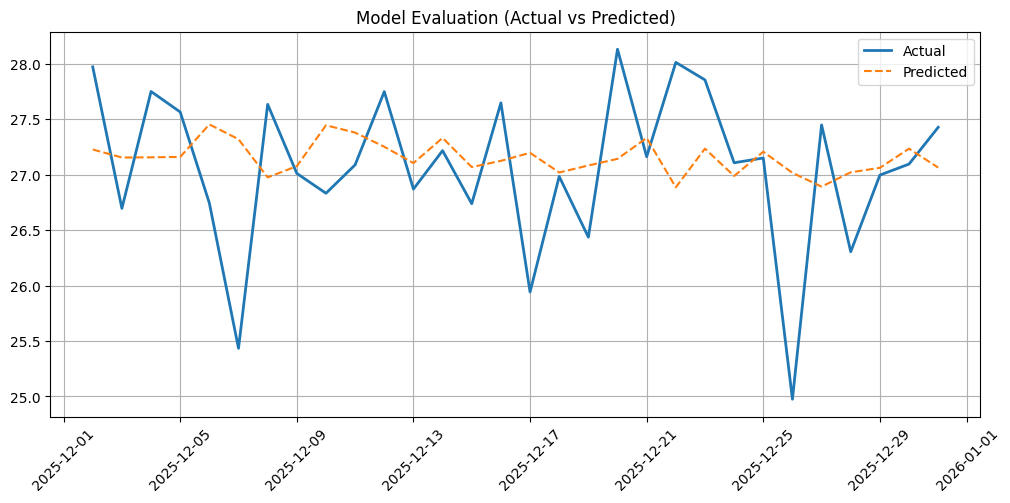

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(test.index, test, label="Actual", linewidth=2)
plt.plot(test.index, pred, label="Predicted", linestyle='--')

plt.title("Model Evaluation (Actual vs Predicted)")
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [30]:
!pip install prophet

In [31]:
from prophet import Prophet
import pandas as pd

In [32]:
df_prophet = ts_daily.reset_index()
df_prophet.columns = ["ds", "y"]

In [33]:
train = df_prophet[:-30]
test  = df_prophet[-30:]
model = Prophet()
model.fit(train)

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [35]:
future = model.make_future_dataframe(periods=30)
forecast = model.predict(future)
pred = forecast[['ds', 'yhat']].tail(30)

pred_values = pred['yhat'].values
test_values = test['y'].values

In [36]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(test_values, pred_values)
rmse = np.sqrt(mean_squared_error(test_values, pred_values))
mape = np.mean(np.abs((test_values - pred_values) / test_values)) * 100

print("Prophet MAE:", mae)
print("Prophet RMSE:", rmse)
print("Prophet MAPE:", mape)

Prophet MAE: 0.5526122534126052
Prophet RMSE: 0.7257005963354219
Prophet MAPE: 2.066675335404731


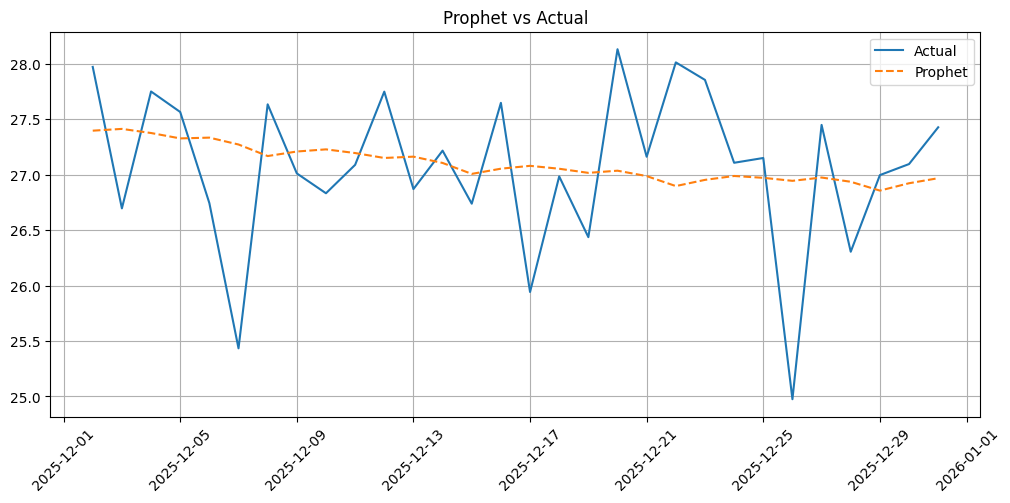

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(test['ds'], test_values, label="Actual")
plt.plot(test['ds'], pred_values, label="Prophet", linestyle='--')
plt.legend()
plt.title("Prophet vs Actual")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [42]:
actual = test['y'].values
predicted = pred_values
dates = test['ds']
errors = np.abs(actual - predicted)
threshold = np.mean(errors) + 2 * np.std(errors)
anomalies = errors > threshold

In [46]:
anomaly_points = np.where(anomalies)[0]
print("Anomaly indices:", anomaly_points)

Anomaly indices: [ 5 24]


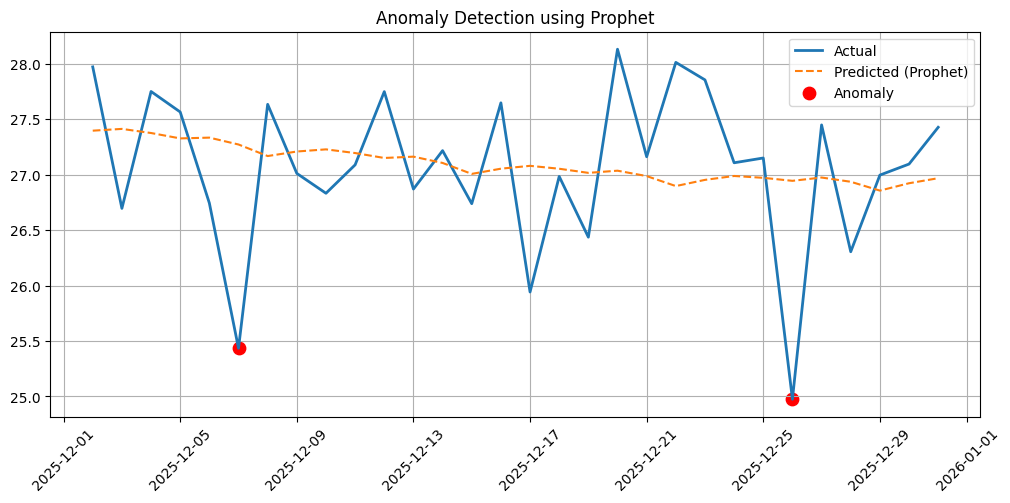

In [44]:
plt.figure(figsize=(12,5))
plt.plot(dates, actual, label="Actual", linewidth=2)
plt.plot(dates, predicted, label="Predicted (Prophet)", linestyle='--')
plt.scatter(dates[anomalies],
            actual[anomalies],
            color='red',
            label="Anomaly",
            s=80)

plt.legend()
plt.title("Anomaly Detection using Prophet")
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

In [49]:
anomaly_dates = dates[anomalies]
anomaly_values = actual[anomalies]
for date, act, pred in zip(dates[anomalies], actual[anomalies], predicted[anomalies]):
    diff = act - pred
    print(f"Anomaly on {date.date()} | Deviation: {diff:.2f} °C")

Anomaly on 2025-12-07 | Deviation: -1.84 °C
Anomaly on 2025-12-26 | Deviation: -1.97 °C


In [50]:
import pickle

with open("prophet_model.pkl", "wb") as f:
    pickle.dump(model, f)

In [51]:
import pickle

with open("sarima_model.pkl", "wb") as f:
    pickle.dump(model_fit, f)